In [2]:
# !pip install -q timm tensorboard

In [3]:
import os
import json
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import timm
from tqdm.auto import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
DATASET_PATH = "processed_dataset" 
BATCH_SIZE = 32
IMAGE_SIZE = 224
EPOCHS = 25
LEARNING_RATE = 1e-4
NUM_WORKERS = 2
MODEL_NAME = "efficientnet_b0"
MODEL_SAVE_PATH = "models"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(
        distortion_scale=0.2,
        p=0.3
    ),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"val"),
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"test"),
    transform=val_transform
)

In [8]:
class_names = train_dataset.classes
print(class_names)

with open("classes.json","w") as f:
    json.dump(class_names,f)

['BellPepper', 'Chilli', 'Cotton', 'Groundnut', 'Potato', 'Tomato']


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [10]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=len(class_names)
)

model.to(device)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bi

In [11]:
# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Fine-tune last EfficientNet blocks
for param in model.blocks[-2:].parameters():
    param.requires_grad = True

# Conv head
for param in model.conv_head.parameters():
    param.requires_grad = True

# Final classifier
for param in model.classifier.parameters():
    param.requires_grad = True

In [12]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_dataset.targets
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

In [14]:
optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

In [15]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

In [16]:
scaler = torch.cuda.amp.GradScaler()

C:\Users\kunj lunagariya\AppData\Local\Temp\ipykernel_30080\2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [17]:
def train_one_epoch():
    model.train()
    running_loss=0
    correct=0
    total=0
    loop=tqdm(train_loader)
    for images,labels in loop:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs=model(images)
            loss=criterion(outputs,labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss+=loss.item()
        _,pred=outputs.max(1)
        total+=labels.size(0)
        correct+=pred.eq(labels).sum().item()
        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )
    return running_loss/len(train_loader),100*correct/total

In [18]:
def validate():
    model.eval()
    running_loss=0
    correct=0
    total=0
    with torch.no_grad():
        for images,labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion(outputs,labels)
            running_loss+=loss.item()
            _,pred=outputs.max(1)
            total+=labels.size(0)
            correct+=pred.eq(labels).sum().item()
    return running_loss/len(val_loader),100*correct/total

In [19]:
best_loss=np.inf
patience=5
counter=0

In [20]:
history={
    "train_loss":[],
    "train_acc":[],
    "val_loss":[],
    "val_acc":[]
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss,train_acc=train_one_epoch()
    val_loss,val_acc=validate()
    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print()
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}")
    if val_loss<best_loss:
        best_loss=val_loss
        counter=0
        torch.save({
            "model":model.state_dict(),
            "optimizer":optimizer.state_dict(),
            "epoch":epoch,
            "best_loss":best_loss
        },
        "models/crop_identifier_best.pth")
        print("Best Model Saved")
    else:
        counter+=1
    if counter>=patience:
        print("Early Stopping")
        break


Epoch 1/25


  0%|          | 0/281 [00:00<?, ?it/s]C:\Users\kunj lunagariya\AppData\Local\Temp\ipykernel_30080\3059382095.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 281/281 [00:43<00:00,  6.40it/s, acc=53.7, loss=1.6]  



Train Loss : 1.9905
Train Acc  : 53.70
Val Loss   : 1.1663
Val Acc    : 78.43
Best Model Saved

Epoch 2/25


100%|██████████| 281/281 [00:29<00:00,  9.51it/s, acc=78, loss=1.88]   



Train Loss : 1.1604
Train Acc  : 77.96
Val Loss   : 0.9940
Val Acc    : 88.24
Best Model Saved

Epoch 3/25


...


Train Loss : 0.5623
Train Acc  : 97.35
Val Loss   : 0.5798
Val Acc    : 96.88
Best Model Saved

Epoch 24/25


100%|██████████| 281/281 [00:28<00:00,  9.90it/s, acc=97.5, loss=0.516]



Train Loss : 0.5590
Train Acc  : 97.49
Val Loss   : 0.5798
Val Acc    : 97.06

Epoch 25/25


100%|██████████| 281/281 [00:28<00:00,  9.96it/s, acc=97.1, loss=0.607]



Train Loss : 0.5560
Train Acc  : 97.12
Val Loss   : 0.5603
Val Acc    : 97.24
Best Model Saved


In [21]:
with open("training_history.json","w") as f:
    json.dump(history,f)

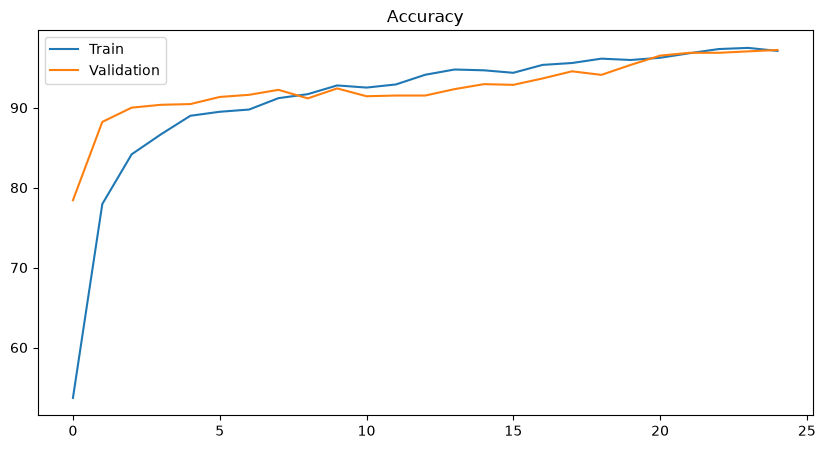

In [22]:
plt.figure(figsize=(10,5))
plt.plot(history["train_acc"],label="Train")
plt.plot(history["val_acc"],label="Validation")
plt.legend()
plt.title("Accuracy")
plt.show()

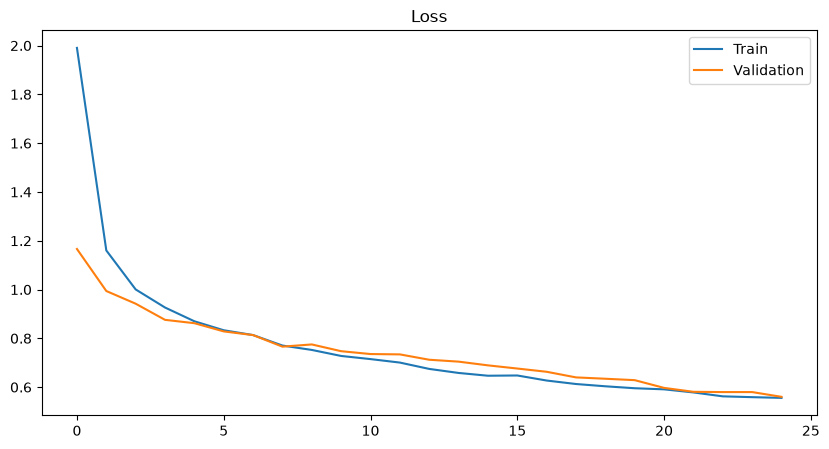

In [23]:
plt.figure(figsize=(10,5))
plt.plot(history["train_loss"],label="Train")
plt.plot(history["val_loss"],label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

In [24]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

EPOCHS = 10

# Re-run the training loop (Cell 18)